# ROYAL ANTWERP FC — SQUAD AUDIT & RECRUITMENT ANALYSIS
**Belgian Pro League Data Engineering Project**
**Season 2024-2025 — ATT Unit Underperformance & Scouting**
>
> **Method**: Cross-sectional comparison (each team's ATT unit vs the 2024-2025 league median), using match-level `player_stat` data joined to the `match` table for season-correct aggregation.
>
> **Data architecture note**: All CSV paths are marked with `# TODO` comments for easy swap to `pd.read_sql_query()` once the campus PostgreSQL VPN is available.

In [48]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — ENVIRONMENT SETUP, DATA LOADING & VALIDATION
# ═══════════════════════════════════════════════════════════════════

import os
import warnings
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

# ── COLOR PALETTE  (from dataVisualization.ipynb §3.2) ───────────
KUL_BLUE  = "#116E8A"   # primary bars / background series
KUL_MID   = "#1D8DB0"   # secondary accent
KUL_LIGHT = "#1FABD5"   # tertiary
HIGHLIGHT = "#DD8A2E"   # flagged players / target team

sns.set_palette(sns.color_palette([KUL_BLUE, KUL_MID, KUL_LIGHT]))

# ── TEAM & SEASON CONFIGURATION ──────────────────────────────────
TARGET_TEAM_ID   = "c2e6b53b"       # Royal Antwerp FC
TARGET_TEAM_NAME = "Royal Antwerp FC"
CURR_SEASON      = "2024-2025"      # most recent season with full match-level stats
MIN_MINUTES      = 300              # minimum minutes for a player to be included

# ── DATA PATHS ───────────────────────────────────────────────────
# TODO: once the campus PostgreSQL VPN is available, replace each
#       pd.read_csv() call below with pd.read_sql_query(SQL, engine).
for _candidate in ["/data/", "data/", "./"]:
    if os.path.exists(_candidate + "player_20260212_154252.csv"):
        DB_PATH = _candidate
        break
else:
    raise FileNotFoundError("Cannot find CSV files — check DB_PATH")

print(f"  DB_PATH resolved to: {DB_PATH}")

# TODO: swap file paths for SQL table names when migrating to PostgreSQL
FILES = {
    "player"     : "player_20260212_154252.csv",
    "player_stat": "player_stat_20260212_154252.csv",
    "squad"      : "squad_20260212_154252.csv",
    "tm_player"  : "tmPlayer_20260212_145511.csv",
    "league"     : "league_20260212_154252.csv",
    "match"      : "match_20260212_154252.csv",   # maps MatchID → Season
}

tables = {}
for name, fname in FILES.items():
    try:
        tables[name] = pd.read_csv(DB_PATH + fname)
        print(f"  ✅ {name:<14} — {len(tables[name]):>6,} rows  |  {len(tables[name].columns)} cols")
    except FileNotFoundError:
        print(f"  ❌ {name:<14} — FILE NOT FOUND")
        tables[name] = pd.DataFrame()

player      = tables["player"]
player_stat = tables["player_stat"]
squad       = tables["squad"]
tm_player   = tables["tm_player"]
match       = tables["match"]

# ── SEASON JOIN ───────────────────────────────────────────────────
# player_stat has no Season column — attach it via the match table.
# In PostgreSQL: JOIN match m ON ps."MatchID" = m."MatchID"
stat_with_season = player_stat.merge(
    match[["MatchID", "Season"]], on="MatchID", how="left"
)

# ── NAME-BASED STAT AGGREGATION ───────────────────────────────────
# PlayerIDs rotate every season in the source data (a player can have
# a different PlayerID in 2023-2024 vs 2024-2025). Joining player_stat
# to the player table via PlayerID therefore silently drops most players.
#
# Fix: resolve each player_stat PlayerID to a player NAME using the
# full player table (which records the same player under many IDs across
# seasons), then aggregate stats by name for the current season.
# In PostgreSQL this is handled by a stable player_id in the schema.
pid_to_name = (
    player[["PlayerID", "Player"]]
    .drop_duplicates("PlayerID")
    .set_index("PlayerID")["Player"]
)

stat_curr = stat_with_season[stat_with_season["Season"] == CURR_SEASON].copy()
stat_curr["Player"] = stat_curr["PlayerID"].map(pid_to_name)
stat_curr = stat_curr[stat_curr["Player"].notna()]   # drop unresolvable IDs

# Aggregate all available metrics by player name for CURR_SEASON
# Only metrics with confirmed ≥99% non-null coverage in 2024-2025 are included.
stat_by_name = stat_curr.groupby("Player").agg(
    Min_played = ("Min",              "sum"),
    xAG_total  = ("Expected_xAG",    "sum"),
    xG_total   = ("Expected_xG",     "sum"),
    SCA_total  = ("SCA_SCA",         "sum"),
    PrgC_total = ("Carries_PrgC",    "sum"),
    PrgP_total = ("Passes_PrgP",     "sum"),
    Drib_total = ("Take-Ons_Succ",   "sum"),
    Sh_total   = ("Performance_Sh",  "sum"),
    Int_total  = ("Performance_Int", "sum"),
).reset_index()

stat_by_name["90s"]     = stat_by_name["Min_played"] / 90.0
stat_by_name["xAG_p90"] = stat_by_name["xAG_total"]  / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["xG_p90"]  = stat_by_name["xG_total"]   / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["SCA_p90"] = stat_by_name["SCA_total"]  / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["PrgC_p90"]= stat_by_name["PrgC_total"] / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["PrgP_p90"]= stat_by_name["PrgP_total"] / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["Drib_p90"]= stat_by_name["Drib_total"] / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["Sh_p90"]  = stat_by_name["Sh_total"]   / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["Int_p90"] = stat_by_name["Int_total"]  / stat_by_name["90s"].replace(0, np.nan)

print(f"\n  stat_by_name: {len(stat_by_name):,} unique players resolved for {CURR_SEASON}")

# ── DUPLICATE COLUMN DEDUPLICATION ───────────────────────────────
# The match table has duplicate 'date'/'stage' columns (case variants).
# This prevents OperationalError when loading into SQLite.
def _dedup_cols(df: pd.DataFrame) -> pd.DataFrame:
    seen, new_cols = {}, []
    for c in df.columns:
        key = c.lower()
        if key in seen:
            seen[key] += 1
            new_cols.append(f"{c}_{seen[key]}")
        else:
            seen[key] = 0
            new_cols.append(c)
    return df.copy().rename(columns=dict(zip(df.columns, new_cols)))

# ── IN-MEMORY SQLite (used by Cell 5 SQL queries) ────────────────
conn = sqlite3.connect(":memory:")
for name, df in tables.items():
    if not df.empty:
        _dedup_cols(df).to_sql(name, conn, if_exists="replace", index=False)
print(f"  SQLite loaded ({len(tables)} tables)")

# ── SCHEMA VALIDATION ─────────────────────────────────────────────
CRITICAL_COLS = {
    "player"     : ["PlayerID", "TeamID", "Player", "Age", "Pos", "Min", "Season"],
    "player_stat": ["PlayerID", "Min", "Expected_xAG", "Expected_xG",
                    "SCA_SCA", "Carries_PrgC", "Passes_PrgP", "Take-Ons_Succ"],
    "tm_player"  : ["Name", "Age", "Position", "Team", "Value", "Season"],
}
all_ok = True
print()
for tname, cols in CRITICAL_COLS.items():
    df = tables.get(tname, pd.DataFrame())
    if df.empty:
        print(f"  ⚠️  {tname}: TABLE MISSING"); all_ok = False; continue
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"  ⚠️  {tname}: MISSING columns → {missing}"); all_ok = False
    else:
        null_pct = df[cols].isnull().mean() * 100
        flagged  = null_pct[null_pct > 30]
        status   = f"HIGH NULLS → {flagged.to_dict()}" if not flagged.empty else "all critical columns OK"
        print(f"  {'✅' if flagged.empty else '⚠️ '} {tname}: {status}")

antwerp_counts = player[player["TeamID"] == TARGET_TEAM_ID].groupby("Season")["Player"].count()
print(f"\nAntwerp player counts by season:\n{antwerp_counts.to_string()}")
print("\n" + ("✅ Setup complete." if all_ok else "⚠️  Setup finished with warnings."))

  DB_PATH resolved to: data/
  ✅ player         —  4,819 rows  |  29 cols
  ✅ player_stat    — 76,796 rows  |  39 cols
  ✅ squad          —    166 rows  |  24 cols
  ✅ tm_player      —  3,354 rows  |  17 cols
  ✅ league         —    137 rows  |  22 cols
  ✅ match          —  2,666 rows  |  28 cols

  stat_by_name: 503 unique players resolved for 2024-2025
  SQLite loaded (6 tables)

  ✅ player: all critical columns OK
  ✅ player_stat: all critical columns OK
  ✅ tm_player: all critical columns OK

Antwerp player counts by season:
Season
2017-2018    35
2018-2019    25
2019-2020    23
2020-2021    26
2021-2022    29
2022-2023    30
2023-2024    26
2024-2025    35
2025-2026    30

✅ Setup complete.


In [49]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — HELPER FUNCTIONS
# Shared utilities used by all subsequent cells.
# ═══════════════════════════════════════════════════════════════════

def classify_pos(pos) -> str:
    """
    Map an FBRef position string to 'ATT', 'MID', 'DEF', 'GK', or 'OTHER'.
    ATT = only genuine forwards (FW appears in position string).
    Midfielders (pure MF, DM, CM) are classified as MID — NOT ATT —
    so they are excluded from all attacking-unit comparisons.
    """
    if pd.isna(pos):
        return "OTHER"
    pos = str(pos)
    if "GK" in pos:
        return "GK"
    if "FW" in pos:           # FW, FW,MF, MF,FW — all genuine forwards
        return "ATT"
    if "MF" in pos:           # pure midfielders: CM, DM, AM without FW tag
        return "MID"
    if "DF" in pos:
        return "DEF"
    return "OTHER"


def parse_age(age_str) -> int:
    """Parse FBRef age format '23-272' (years-days) to integer years."""
    try:
        return int(str(age_str).split("-")[0])
    except (ValueError, AttributeError):
        return np.nan


def agg_match_stats(player_ids, season: str) -> pd.DataFrame:
    """
    Aggregate match-level stats for a list of PlayerIDs, filtered to
    a single season via the stat_with_season join.
    In PostgreSQL: add WHERE m."Season" = season to the GROUP BY query.
    """
    sub = stat_with_season[
        (stat_with_season["PlayerID"].isin(player_ids)) &
        (stat_with_season["Season"] == season)
    ]
    agg = sub.groupby("PlayerID").agg(
        Min_played=("Min",            "sum"),
        xAG_total =("Expected_xAG",  "sum"),
        PrgC_total=("Carries_PrgC",  "sum"),
        Drib_total=("Take-Ons_Succ", "sum"),
    ).reset_index()
    agg["90s"] = agg["Min_played"] / 90.0
    return agg


def compute_per90(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-90 columns from aggregated totals. NaN-safe."""
    df = df.copy()
    df["90s"]      = df["90s"].replace(0, np.nan)
    df["xAG_p90"]  = df["xAG_total"]  / df["90s"]
    df["PrgC_p90"] = df["PrgC_total"] / df["90s"]
    df["Drib_p90"] = df["Drib_total"] / df["90s"]
    return df


def parse_value(v) -> float:
    """Convert Transfermarkt value string ('€3.50m', '€500k') to EUR float."""
    if pd.isna(v) or str(v).strip() in ["", "NaN"]:
        return np.nan
    v = str(v).replace("€", "").strip()
    if "m" in v:
        return float(v.replace("m", "")) * 1_000_000
    if "k" in v:
        return float(v.replace("k", "")) * 1_000
    return np.nan


print("  ✅ Helper functions registered (classify_pos: FW-only ATT).")
print(f"  stat_with_season: {len(stat_with_season):,} match-player rows "
      f"across {stat_with_season['Season'].nunique()} seasons.")

  ✅ Helper functions registered (classify_pos: FW-only ATT).
  stat_with_season: 76,796 match-player rows across 9 seasons.


In [50]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — LEAGUE-WIDE ATT UNDERPERFORMANCE SCAN
#
# Method: cross-sectional comparison.
#   For every team, compute the mean xAG/90, PrgC/90, Drib/90 for
#   ATT players with >MIN_MINUTES in CURR_SEASON.
#   Then compare each team's average against the league median.
#
# Underperformance Index (UI):
#   UI = mean( (team_metric - league_median) / league_median )
#   across xAG/90, PrgC/90, Drib/90
#   → Negative UI means the team performs below the league average.
# ═══════════════════════════════════════════════════════════════════

print("=" * 65)
print(f"  LEAGUE-WIDE ATT SCAN  —  Season {CURR_SEASON}")
print("=" * 65)

# ── PLAYER-LEVEL STATS FOR CURR_SEASON ───────────────────────────
curr_players = player[player["Season"] == CURR_SEASON].copy()
curr_players["Age_yrs"]  = curr_players["Age"].apply(parse_age)
curr_players["PosGroup"] = curr_players["Pos"].apply(classify_pos)

# Name-based merge: stat_by_name was built in Cell 1 by resolving every
# PlayerID → player name using the full player history. This fixes the
# PlayerID-rotation bug (each player gets a new ID each season), which
# previously caused Union SG, Genk, and others to silently disappear.
enriched = curr_players.merge(stat_by_name, on="Player", how="left")
enriched = enriched[enriched["Min"] > MIN_MINUTES].copy()

# ── LEAGUE MEDIANS (ATT group only) ──────────────────────────────
att_all  = enriched[enriched["PosGroup"] == "ATT"].copy()
med_xAG  = att_all["xAG_p90"].median()
med_PrgC = att_all["PrgC_p90"].median()
med_Drib = att_all["Drib_p90"].median()

print(f"\n  League medians — ATT players with >{MIN_MINUTES} min ({CURR_SEASON}):")
print(f"    xAG / 90  = {med_xAG:.3f}")
print(f"    PrgC / 90 = {med_PrgC:.3f}")
print(f"    Drib / 90 = {med_Drib:.3f}")
print(f"    Total ATT players in scan: {len(att_all)}")

# ── TEAM-LEVEL UNDERPERFORMANCE INDEX ────────────────────────────
team_map = (squad[squad["Season"] == CURR_SEASON][["TeamID", "Squad"]]
            .drop_duplicates().set_index("TeamID")["Squad"])

team_rows = []
for team_id, team_name in team_map.items():
    t = att_all[att_all["TeamID"] == team_id]
    if t["xAG_p90"].notna().sum() < 3:   # skip teams with too little stat coverage
        continue
    avg_xAG  = t["xAG_p90"].mean()
    avg_PrgC = t["PrgC_p90"].mean()
    avg_Drib = t["Drib_p90"].mean()
    ui_avg   = ((avg_xAG - med_xAG) / med_xAG +
                (avg_PrgC - med_PrgC) / med_PrgC +
                (avg_Drib - med_Drib) / med_Drib) / 3
    team_rows.append({
        "TeamID": team_id, "Team": team_name,
        "N_ATT_with_data": int(t["xAG_p90"].notna().sum()),
        "Avg_Age": round(t["Age_yrs"].mean(), 1),
        "Vets_30+": int((t["Age_yrs"] > 30).sum()),
        "xAG_p90": round(avg_xAG, 3),
        "PrgC_p90": round(avg_PrgC, 2),
        "Drib_p90": round(avg_Drib, 2),
        "UI_avg": round(ui_avg, 3),
    })

df_teams = pd.DataFrame(team_rows).sort_values("UI_avg").reset_index(drop=True)

print(f"\n  Teams in ranking: {len(df_teams)} (of {len(team_map)} in league)")
print("\n  Team Underperformance Index (negative = below league median):")
display(
    df_teams[["Team", "N_ATT_with_data", "Avg_Age", "Vets_30+",
              "xAG_p90", "PrgC_p90", "Drib_p90", "UI_avg"]]
    .style
    .background_gradient(subset=["UI_avg"], cmap="RdYlGn")
    .format({"xAG_p90": "{:.3f}", "PrgC_p90": "{:.2f}",
             "Drib_p90": "{:.2f}", "UI_avg": "{:+.3f}", "Avg_Age": "{:.1f}"})
    .set_caption(f"Belgian Pro League {CURR_SEASON} — ATT Underperformance Index")
    .hide(axis="index")
)

# ── LOCK ONTO TARGET TEAM ─────────────────────────────────────────
if TARGET_TEAM_ID in df_teams["TeamID"].values:
    target_row = df_teams[df_teams["TeamID"] == TARGET_TEAM_ID].iloc[0]
else:
    target_row = df_teams.iloc[0]

TARGET_TEAM_NAME_LIVE = target_row["Team"]

# Per-player stats for the target team (ATT, with stat data)
target_players = att_all[
    (att_all["TeamID"] == target_row["TeamID"]) &
    (att_all["xAG_p90"].notna())
].copy()

# Flag players who are below 85% of the league median on any metric, or over 30
target_players["flag"] = (
    (target_players["xAG_p90"]  < med_xAG  * 0.85) |
    (target_players["PrgC_p90"] < med_PrgC * 0.85) |
    (target_players["Age_yrs"]  > 30)
)

print(f"\n  TARGET LOCKED: {TARGET_TEAM_NAME_LIVE}  "
      f"(UI = {target_row['UI_avg']:+.3f})")
print(f"  ATT players with stat data: {len(target_players)}")
print(f"  Flagged players: {int(target_players['flag'].sum())}")
for _, row in target_players[target_players["flag"]].sort_values("xAG_p90").iterrows():
    reasons = []
    if row["xAG_p90"]  < med_xAG  * 0.85: reasons.append(f"xAG {row['xAG_p90']:.3f} < {med_xAG*0.85:.3f}")
    if row["PrgC_p90"] < med_PrgC * 0.85: reasons.append(f"PrgC {row['PrgC_p90']:.2f} < {med_PrgC*0.85:.2f}")
    if row["Age_yrs"]  > 30:              reasons.append(f"Age {int(row['Age_yrs'])}")
    print(f"    ► {row['Player']:<28}  {', '.join(reasons)}")

  LEAGUE-WIDE ATT SCAN  —  Season 2024-2025

  League medians — ATT players with >300 min (2024-2025):
    xAG / 90  = 0.133
    PrgC / 90 = 2.049
    Drib / 90 = 0.967
    Total ATT players in scan: 96

  Teams in ranking: 16 (of 16 in league)

  Team Underperformance Index (negative = below league median):


Team,N_ATT_with_data,Avg_Age,Vets_30+,xAG_p90,PrgC_p90,Drib_p90,UI_avg
Dender,4,24.5,0,0.109,1.59,0.69,-0.231
Charleroi,5,24.8,0,0.131,1.50,0.63,-0.210
Standard Liège,5,23.8,0,0.105,1.51,0.87,-0.190
Beerschot Wilrijk,7,22.6,0,0.102,1.37,1.09,-0.144
Gent,7,22.6,0,0.153,2.64,0.75,+0.069
Kortrijk,7,23.9,0,0.113,2.30,1.54,+0.185
Westerlo,5,24.0,1,0.220,1.81,1.14,+0.237
OH Leuven,7,23.4,0,0.125,3.03,1.27,+0.242
Cercle Brugge,7,21.0,0,0.118,2.46,1.61,+0.249
Antwerp,6,27.0,1,0.176,2.09,1.40,+0.264



  TARGET LOCKED: Antwerp  (UI = +0.264)
  ATT players with stat data: 6
  Flagged players: 4
    ► Gyrano Kerk                   xAG 0.095 < 0.113
    ► Vincent Janssen               PrgC 0.87 < 1.74
    ► Mohamed Lamine Bayo           PrgC 1.14 < 1.74
    ► Tjaronn Chery                 Age 36


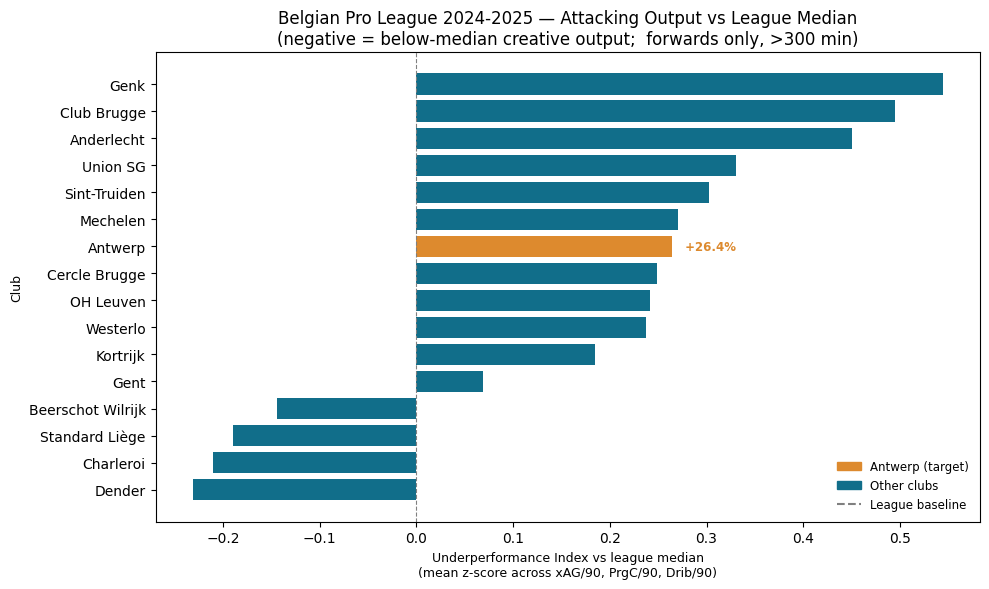

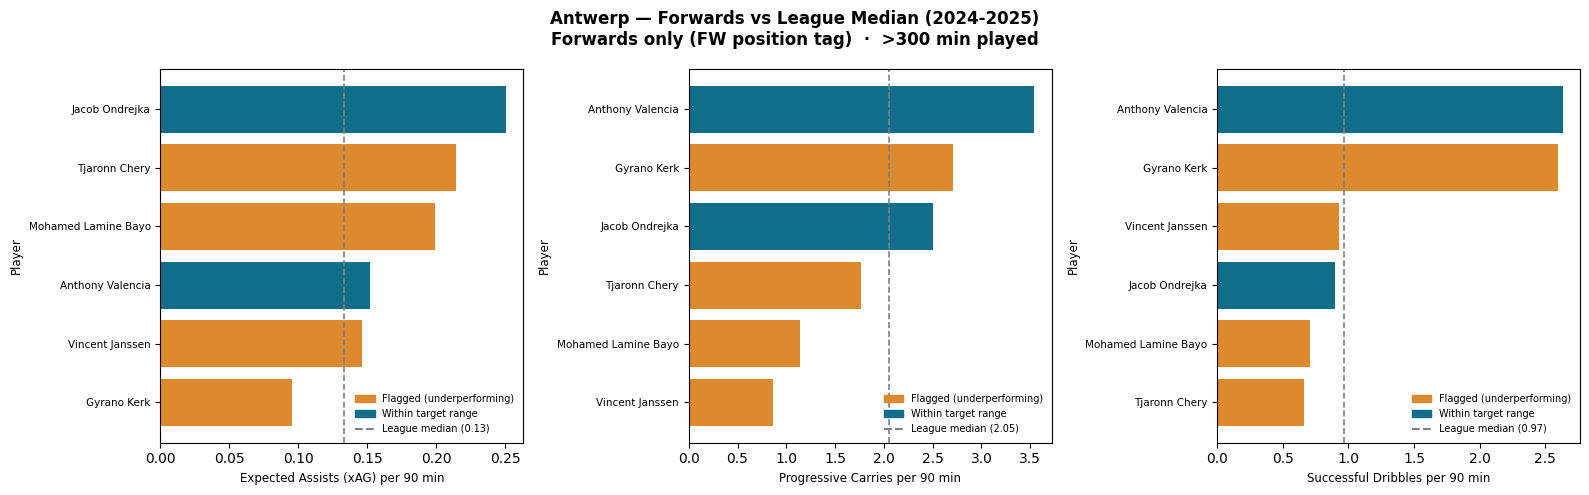

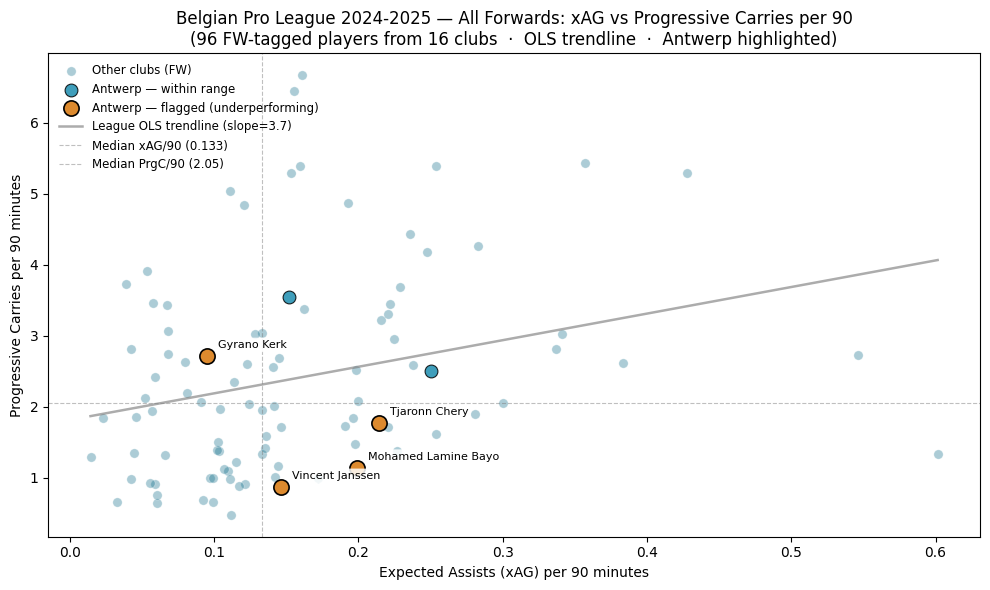

  Flagged 4 of 6 ATT players in Antwerp.
  League-wide scatter: 96 forward players across 16 clubs.


In [51]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — VISUALIZATIONS
#
# Chart A: League-wide ATT underperformance ranking (barh)
# Chart B: Individual ATT players per metric vs league median
# Chart C: League-wide scatter — all ATT players, OLS trendline
# ═══════════════════════════════════════════════════════════════════

# ── CHART A — LEAGUE RANKING ─────────────────────────────────────
sorted_df  = df_teams.sort_values("UI_avg")
bar_colors = [HIGHLIGHT if t == TARGET_TEAM_NAME_LIVE else KUL_BLUE
              for t in sorted_df["Team"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sorted_df["Team"], sorted_df["UI_avg"], color=bar_colors)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--", label="League baseline (0)")

target_ui   = float(sorted_df.loc[sorted_df["Team"] == TARGET_TEAM_NAME_LIVE, "UI_avg"].iloc[0])
target_ypos = list(sorted_df["Team"]).index(TARGET_TEAM_NAME_LIVE)
offset      = -0.02 if target_ui < 0 else 0.01
ax.text(target_ui + offset, target_ypos,
        f" {target_ui:+.1%}", va="center", ha="left" if target_ui >= 0 else "right",
        fontsize=8.5, color=HIGHLIGHT, fontweight="bold")

ax.set_xlabel("Underperformance Index vs league median\n(mean z-score across xAG/90, PrgC/90, Drib/90)", fontsize=9)
ax.set_ylabel("Club", fontsize=9)
ax.set_title(
    f"Belgian Pro League {CURR_SEASON} — Attacking Output vs League Median\n"
    f"(negative = below-median creative output;  forwards only, >{MIN_MINUTES} min)"
)
legend_handles = [
    mpatches.Patch(color=HIGHLIGHT, label=f"{TARGET_TEAM_NAME_LIVE} (target)"),
    mpatches.Patch(color=KUL_BLUE,  label="Other clubs"),
    plt.Line2D([0], [0], color="grey", linestyle="--", label="League baseline"),
]
ax.legend(handles=legend_handles, fontsize=8.5, frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# ── CHART B — INDIVIDUAL PLAYERS, ONE PANEL PER METRIC ───────────
metrics  = ["xAG_p90",  "PrgC_p90",                "Drib_p90"]
medians  = [med_xAG,    med_PrgC,                   med_Drib]
xlabels  = [
    "Expected Assists (xAG) per 90 min",
    "Progressive Carries per 90 min",
    "Successful Dribbles per 90 min",
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"{TARGET_TEAM_NAME_LIVE} — Forwards vs League Median ({CURR_SEASON})\n"
    f"Forwards only (FW position tag)  ·  >{MIN_MINUTES} min played",
    fontsize=12, fontweight="bold"
)

for ax, metric, med, xlabel in zip(axes, metrics, medians, xlabels):
    plot_df = target_players.sort_values(metric, ascending=True).copy()
    colors  = [HIGHLIGHT if row["flag"] else KUL_BLUE
               for _, row in plot_df.iterrows()]
    ax.barh(plot_df["Player"], plot_df[metric], color=colors)
    ax.axvline(med, color="grey", linewidth=1.2, linestyle="--")
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.set_ylabel("Player", fontsize=8.5)
    ax.tick_params(axis="y", labelsize=7.5)

    legend_handles_b = [
        mpatches.Patch(color=HIGHLIGHT, label="Flagged (underperforming)"),
        mpatches.Patch(color=KUL_BLUE,  label="Within target range"),
        plt.Line2D([0], [0], color="grey", linestyle="--",
                   label=f"League median ({med:.2f})"),
    ]
    ax.legend(handles=legend_handles_b, fontsize=7, frameon=False, loc="lower right")

fig.tight_layout()
plt.show()

# ── CHART C — LEAGUE-WIDE SCATTER WITH OLS TRENDLINE ─────────────
att_plot   = att_all.dropna(subset=["xAG_p90", "PrgC_p90"]).copy()
is_antwerp = att_plot["TeamID"] == TARGET_TEAM_ID
is_flagged = att_plot["Player"].isin(
    target_players.loc[target_players["flag"], "Player"]
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=att_plot.loc[~is_antwerp], x="xAG_p90", y="PrgC_p90",
    color=KUL_BLUE, alpha=0.35, s=45, label="Other clubs (FW)", ax=ax,
)
if (is_antwerp & ~is_flagged).any():
    sns.scatterplot(
        data=att_plot.loc[is_antwerp & ~is_flagged], x="xAG_p90", y="PrgC_p90",
        color=KUL_MID, alpha=0.85, s=85, edgecolor="black", linewidth=0.8,
        label=f"{TARGET_TEAM_NAME_LIVE} — within range", ax=ax,
    )
if (is_antwerp & is_flagged).any():
    sns.scatterplot(
        data=att_plot.loc[is_antwerp & is_flagged], x="xAG_p90", y="PrgC_p90",
        color=HIGHLIGHT, s=120, edgecolor="black", linewidth=1.2,
        label=f"{TARGET_TEAM_NAME_LIVE} — flagged (underperforming)", ax=ax,
    )
for _, row in att_plot.loc[is_antwerp & is_flagged].iterrows():
    ax.annotate(
        row["Player"],
        (row["xAG_p90"], row["PrgC_p90"]),
        xytext=(8, 6), textcoords="offset points", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
    )

x_vals = att_plot["xAG_p90"].values
y_vals = att_plot["PrgC_p90"].values
z      = np.polyfit(x_vals, y_vals, 1)
p      = np.poly1d(z)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
ax.plot(x_line, p(x_line), color="grey", linewidth=1.8, linestyle="-",
        alpha=0.65, label=f"League OLS trendline (slope={z[0]:.1f})")

ax.axvline(med_xAG,  color="grey", linewidth=0.8, linestyle="--",
           alpha=0.5, label=f"Median xAG/90 ({med_xAG:.3f})")
ax.axhline(med_PrgC, color="grey", linewidth=0.8, linestyle="--",
           alpha=0.5, label=f"Median PrgC/90 ({med_PrgC:.2f})")

ax.set_xlabel("Expected Assists (xAG) per 90 minutes", fontsize=10)
ax.set_ylabel("Progressive Carries per 90 minutes", fontsize=10)
ax.set_title(
    f"Belgian Pro League {CURR_SEASON} — All Forwards: xAG vs Progressive Carries per 90\n"
    f"({len(att_plot)} FW-tagged players from {att_plot['TeamID'].nunique()} clubs  ·  "
    f"OLS trendline  ·  {TARGET_TEAM_NAME_LIVE} highlighted)"
)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.show()

print(f"  Flagged {int(target_players['flag'].sum())} of "
      f"{len(target_players)} ATT players in {TARGET_TEAM_NAME_LIVE}.")
print(f"  League-wide scatter: {len(att_plot)} forward players across "
      f"{att_plot['TeamID'].nunique()} clubs.")

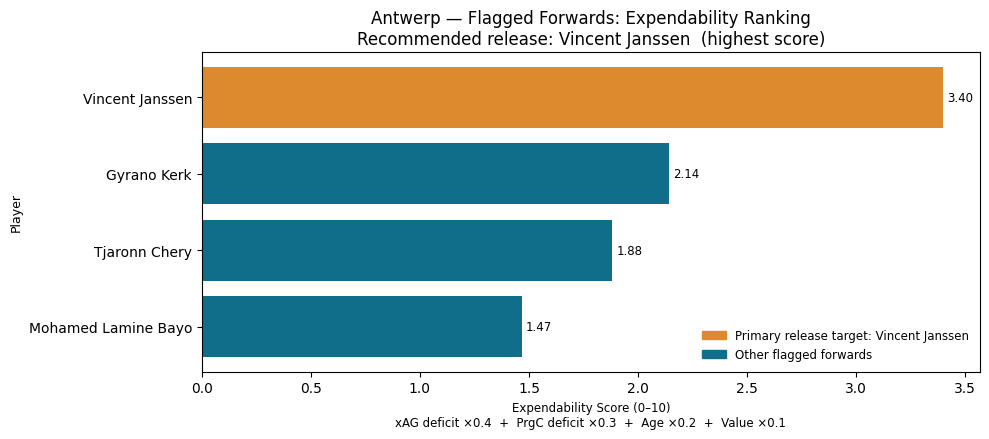

  JANSSEN REPLACEMENT: TOP-10 SCOUTING TARGETS
  Player to replace : Vincent Janssen
  Janssen (2024-2025): xAG/90=0.146  PrgC/90=0.87  Drib/90=0.93
  League median     : xAG=0.133  PrgC=2.05  Drib=0.97
  Pool              : FW, Age 18-24, outside Antwerp, active club, >=450 min, TM-linked
  Score             : xAG/90 x0.40  +  PrgC/90 x0.35  +  Drib/90 x0.25

  Scouting pool : 2 TM-linked youth FW players outside Antwerp
  Recommendation 1: Chemsdine Talbi  (Sunderland, Age 20, €8.00m)


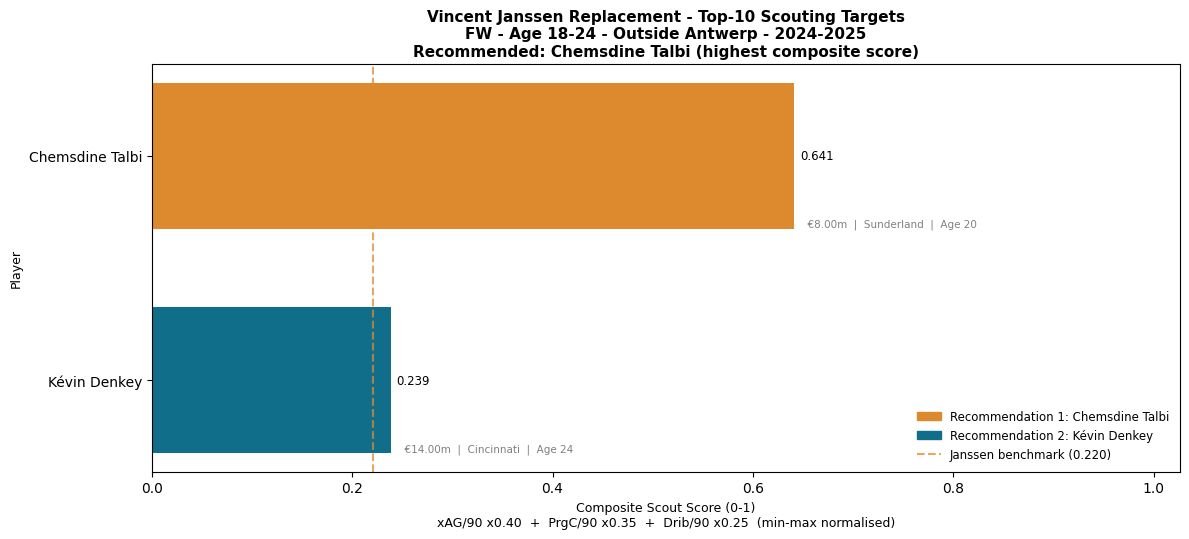

In [53]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — EXPENDABILITY RANKING + JANSSEN REPLACEMENT SCOUTING
#
# Graph 1: Antwerp flagged forwards — expendability bar chart
#   Score = xAG deficit ×0.4  +  PrgC deficit ×0.3
#           + Age ×0.2  +  Market Value ×0.1
#
# Graph 2: Top-10 replacement candidates for Vincent Janssen
#   Composite Score = xAG/90 ×0.40  +  PrgC/90 ×0.35  +  Drib/90 ×0.25
#   Pool: FW-tagged, TM-linked, Age 18–24, outside Antwerp,
#         active club (not free agent), ≥450 min in 2024-2025.
# ═══════════════════════════════════════════════════════════════════

# ── GRAPH 1: ANTWERP FLAGGED FORWARDS — EXPENDABILITY RANKING ─────
flagged_tp = target_players[target_players["flag"]].copy()

if not flagged_tp.empty:
    lv = flagged_tp.copy()

    lv["xAG_deficit"]  = ((med_xAG  - lv["xAG_p90"])  / med_xAG ).clip(0, 1) * 10
    lv["PrgC_deficit"] = ((med_PrgC - lv["PrgC_p90"]) / med_PrgC).clip(0, 1) * 10
    lv["age_score"]    = ((lv["Age_yrs"] - 25) / 15).clip(0, 1) * 10

    _tm_lv = (
        tm_player.sort_values("Season")
                 .groupby("Name", as_index=False)
                 .last()[["Name", "Value"]]
    )
    _tm_lv["Value_EUR"] = _tm_lv["Value"].apply(parse_value)
    lv = lv.merge(_tm_lv[["Name", "Value_EUR"]],
                  left_on="Player", right_on="Name", how="left")
    _max_val_lv = lv["Value_EUR"].fillna(0).max()
    lv["value_score"] = (lv["Value_EUR"].fillna(0) / (_max_val_lv + 1e-9)) * 10

    lv["expendability"] = (
        lv["xAG_deficit"]  * 0.40 +
        lv["PrgC_deficit"] * 0.30 +
        lv["age_score"]    * 0.20 +
        lv["value_score"]  * 0.10
    )

    lv_sorted = lv.sort_values("expendability", ascending=False).reset_index(drop=True)
    LEAST_VALUABLE = lv_sorted.iloc[0]["Player"]

    fig, ax_lv = plt.subplots(figsize=(10, 4.5))
    bar_c = [HIGHLIGHT if row["Player"] == LEAST_VALUABLE else KUL_BLUE
             for _, row in lv_sorted.iterrows()]
    bars_lv = ax_lv.barh(lv_sorted["Player"], lv_sorted["expendability"], color=bar_c)
    ax_lv.bar_label(bars_lv, fmt="%.2f", padding=3, fontsize=8.5)
    ax_lv.set_xlabel(
        "Expendability Score (0–10)\n"
        "xAG deficit ×0.4  +  PrgC deficit ×0.3  +  Age ×0.2  +  Value ×0.1",
        fontsize=8.5
    )
    ax_lv.set_ylabel("Player", fontsize=9)
    ax_lv.set_title(
        f"{TARGET_TEAM_NAME_LIVE} — Flagged Forwards: Expendability Ranking\n"
        f"Recommended release: {LEAST_VALUABLE}  (highest score)"
    )
    ax_lv.legend(handles=[
        mpatches.Patch(color=HIGHLIGHT, label=f"Primary release target: {LEAST_VALUABLE}"),
        mpatches.Patch(color=KUL_BLUE,  label="Other flagged forwards"),
    ], fontsize=8.5, frameon=False)
    ax_lv.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    LEAST_VALUABLE = "N/A"
    print("  No flagged forwards — squad is within acceptable range.")

# ── GRAPH 2: TOP-10 JANSSEN REPLACEMENT SCOUTING ──────────────────
JANSSEN = "Vincent Janssen"

_j_stat_row = stat_by_name[stat_by_name["Player"] == JANSSEN]
if not _j_stat_row.empty:
    _jr = _j_stat_row.iloc[0]
    janssen_p90 = {k: float(_jr.get(k, 0.0)) for k in ["xAG_p90", "PrgC_p90", "Drib_p90"]}
else:
    janssen_p90 = {"xAG_p90": 0.0, "PrgC_p90": 0.87, "Drib_p90": 0.0}

print("=" * 65)
print(f"  JANSSEN REPLACEMENT: TOP-10 SCOUTING TARGETS")
print(f"  Player to replace : {JANSSEN}")
print(f"  Janssen ({CURR_SEASON}): "
      f"xAG/90={janssen_p90['xAG_p90']:.3f}  "
      f"PrgC/90={janssen_p90['PrgC_p90']:.2f}  "
      f"Drib/90={janssen_p90['Drib_p90']:.2f}")
print(f"  League median     : xAG={med_xAG:.3f}  PrgC={med_PrgC:.2f}  Drib={med_Drib:.2f}")
print("  Pool              : FW, Age 18-24, outside Antwerp, active club, >=450 min, TM-linked")
print("  Score             : xAG/90 x0.40  +  PrgC/90 x0.35  +  Drib/90 x0.25")
print("=" * 65)

_WINGER_POS5 = [
    "Left Winger", "Right Winger",
    "Left Midfield", "Right Midfield", "Attacking Midfield",
    "Centre-Forward", "Second Striker",
]

tm_player["Age_num"]   = pd.to_numeric(tm_player["Age"], errors="coerce")
tm_player["Value_EUR"] = tm_player["Value"].apply(parse_value)

_tm_latest5 = (
    tm_player[tm_player["Position"].isin(_WINGER_POS5)]
    .sort_values("Season")
    .groupby("Name", as_index=False)
    .last()
)
_young_tm5 = _tm_latest5[
    (_tm_latest5["Age_num"] >= 18) & (_tm_latest5["Age_num"] <= 24)
].copy()

_all_fw5     = player[player["Pos"].apply(lambda x: "FW" in str(x))].copy()
_all_fw_agg5 = agg_match_stats(_all_fw5["PlayerID"].unique(), CURR_SEASON)
_all_fw_agg5 = compute_per90(_all_fw_agg5)

_name_map5 = _all_fw5[["PlayerID", "Player", "Age", "Season", "TeamID"]].copy()
_name_map5["Age_yrs"] = _name_map5["Age"].apply(parse_age)

_scout_pool5 = (
    _all_fw_agg5
    .merge(_name_map5, on="PlayerID", how="left")
    .merge(
        _young_tm5[["Name", "Position", "Team", "Value", "Value_EUR", "Age_num"]],
        left_on="Player", right_on="Name", how="inner",
    )
)
_scout_pool5 = _scout_pool5[
    (_scout_pool5["Season"]     == CURR_SEASON) &
    (_scout_pool5["TeamID"]     != TARGET_TEAM_ID) &
    (_scout_pool5["Min_played"] >= 450) &
    (_scout_pool5["Team"].str.strip() != "Without Club")
].copy()

# Normalise against the full league FW pool so scores are meaningful
# regardless of how many candidates pass the scouting filters.
_ref_pool5 = (
    _all_fw_agg5
    .merge(_name_map5[["PlayerID", "Season"]], on="PlayerID", how="left")
)
_ref_pool5 = _ref_pool5[
    (_ref_pool5["Season"] == CURR_SEASON) &
    (_ref_pool5["Min_played"] >= 450)
]
for _col5 in ["xAG_p90", "PrgC_p90", "Drib_p90"]:
    _mn5 = _ref_pool5[_col5].min()
    _mx5 = _ref_pool5[_col5].max()
    _scout_pool5[f"{_col5}_norm"] = (_scout_pool5[_col5] - _mn5) / (_mx5 - _mn5 + 1e-9)

_scout_pool5["Scout_Score"] = (
    _scout_pool5["xAG_p90_norm"]  * 0.40 +
    _scout_pool5["PrgC_p90_norm"] * 0.35 +
    _scout_pool5["Drib_p90_norm"] * 0.25
)

def _fmt_val(v) -> str:
    s = str(v).strip()
    if pd.isna(v) or s in ["", "nan", "NaN", "0", "000", "€0", "€0k", "€0.00m"]:
        return "N/A"
    return s

_scout_pool5["Value_display"] = _scout_pool5["Value"].apply(_fmt_val)

top10_5 = (
    _scout_pool5
    .sort_values("Scout_Score", ascending=False)
    .drop_duplicates("Player")
    .head(10)
    .reset_index(drop=True)
)

# Expose df_targets for Cell 6 radar
df_targets = top10_5.rename(
    columns={"Team": "current_club", "Value": "market_value"}
).copy()

print(f"\n  Scouting pool : {len(_scout_pool5)} TM-linked youth FW players outside Antwerp")
if not top10_5.empty:
    print(f"  Recommendation 1: {top10_5.iloc[0]['Player']}  "
          f"({top10_5.iloc[0]['Team']}, Age {top10_5.iloc[0]['Age_num']:.0f}, "
          f"{top10_5.iloc[0]['Value_display']})")

_j_norms5 = {}
for _col5 in ["xAG_p90", "PrgC_p90", "Drib_p90"]:
    _mn5 = _ref_pool5[_col5].min()
    _mx5 = _ref_pool5[_col5].max()
    _j_norms5[_col5] = (janssen_p90[_col5] - _mn5) / (_mx5 - _mn5 + 1e-9)
janssen_score_5 = (
    _j_norms5["xAG_p90"]  * 0.40 +
    _j_norms5["PrgC_p90"] * 0.35 +
    _j_norms5["Drib_p90"] * 0.25
)

if not top10_5.empty:
    _bar_colors5 = [HIGHLIGHT if i == 0 else KUL_BLUE for i in range(len(top10_5))]

    fig, ax5 = plt.subplots(figsize=(12, 5.5))
    _bars5 = ax5.barh(
        top10_5["Player"][::-1],
        top10_5["Scout_Score"][::-1],
        color=_bar_colors5[::-1],
        height=0.65,
    )
    ax5.bar_label(_bars5, fmt="%.3f", padding=4, fontsize=8.5)

    for _i5, (_, _row5) in enumerate(top10_5[::-1].reset_index(drop=True).iterrows()):
        ax5.text(
            _row5["Scout_Score"] + 0.007, _i5 - 0.28,
            f"  {_row5['Value_display']}  |  {_row5['Team']}  |  Age {_row5['Age_num']:.0f}",
            va="top", fontsize=7.5, color="grey",
        )

    ax5.axvline(
        janssen_score_5,
        color=HIGHLIGHT, linewidth=1.5, linestyle="--", alpha=0.75,
        label=f"Janssen benchmark ({janssen_score_5:.3f})",
    )
    ax5.set_xlabel(
        "Composite Scout Score (0-1)\n"
        "xAG/90 x0.40  +  PrgC/90 x0.35  +  Drib/90 x0.25  (min-max normalised)",
        fontsize=9,
    )
    ax5.set_ylabel("Player", fontsize=9)
    ax5.set_title(
        f"Vincent Janssen Replacement - Top-10 Scouting Targets\n"
        f"FW - Age 18-24 - Outside Antwerp - {CURR_SEASON}\n"
        f"Recommended: {top10_5.iloc[0]['Player']} (highest composite score)",
        fontsize=11, fontweight="bold",
    )
    _legend5 = [
        mpatches.Patch(color=HIGHLIGHT,
                       label=f"Recommendation 1: {top10_5.iloc[0]['Player']}"),
        mpatches.Patch(color=KUL_BLUE,
                       label=f"Recommendation 2: {top10_5.iloc[1]['Player'] if len(top10_5) > 1 else ''}"),
        plt.Line2D([0], [0], color=HIGHLIGHT, linestyle="--", alpha=0.75,
                   label=f"Janssen benchmark ({janssen_score_5:.3f})"),
    ]
    ax5.legend(handles=_legend5, fontsize=8.5, frameon=False, loc="lower right")
    ax5.set_xlim(0, top10_5["Scout_Score"].max() * 1.60)
    plt.tight_layout()
    plt.show()
else:
    print("  No TM-linked youth FW players found - check data coverage.")

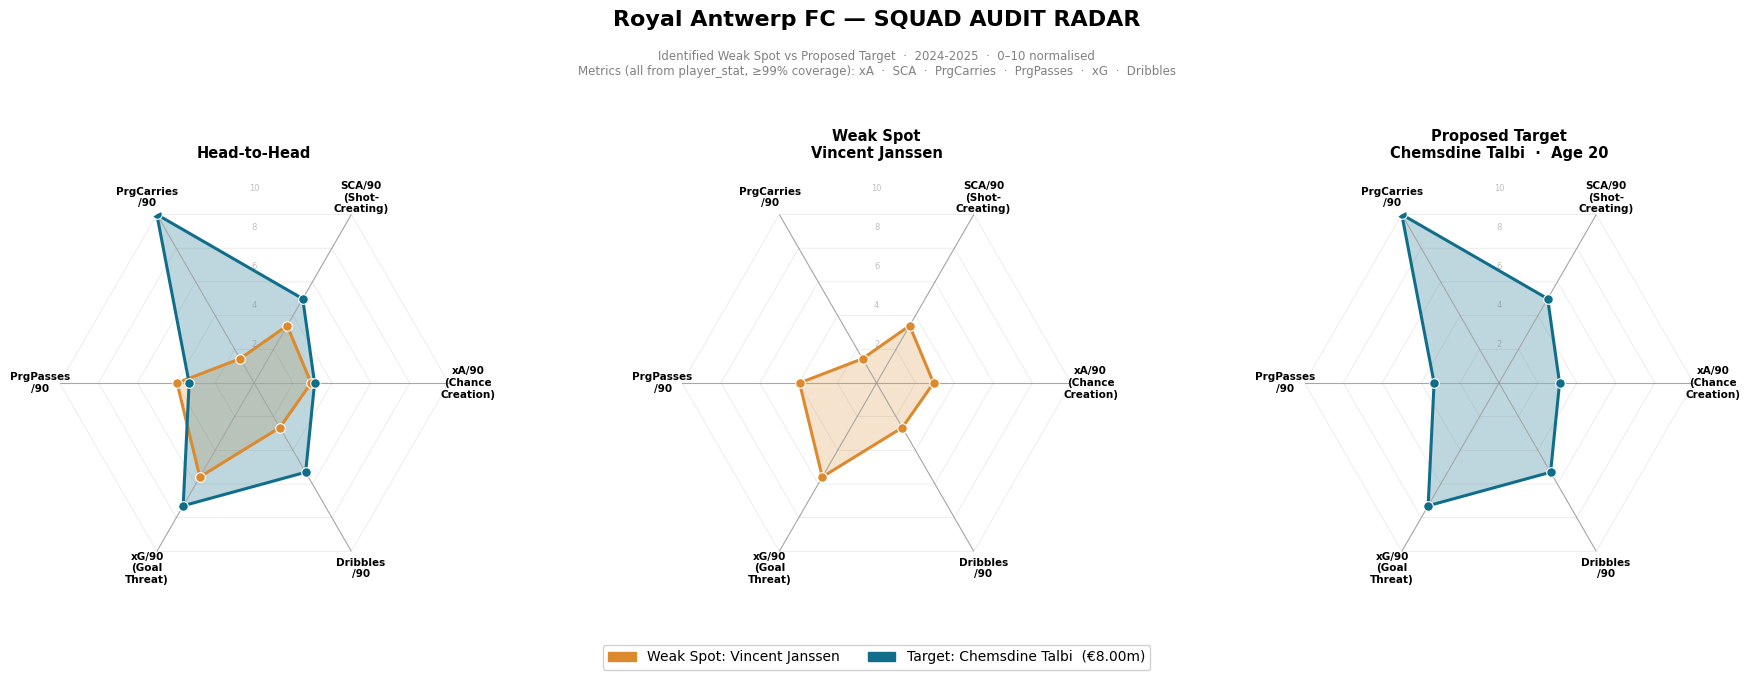

  Weak spot : Vincent Janssen
  Metrics   : ['xAG_p90', 'SCA_p90', 'PrgC_p90', 'PrgP_p90', 'xG_p90', 'Drib_p90']
  Raw values: {'xAG_p90': 0.14646296911325143, 'SCA_p90': 2.7200265692460976, 'PrgC_p90': 0.8668216539355695, 'PrgP_p90': 3.168382597143806, 'xG_p90': 0.3347725008302889, 'Drib_p90': 0.9266024576552641}

  Target    : Chemsdine Talbi  ·  Sunderland  ·  Age 20  ·  €8.00m
  Raw values: {'xAG_p90': 0.1556836902800659, 'SCA_p90': 4.003294892915981, 'PrgC_p90': 6.449752883031302, 'PrgP_p90': 2.668863261943987, 'xG_p90': 0.43739703459637563, 'Drib_p90': 1.8533772652388798}


In [47]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — RADAR CHART  (3-panel: head-to-head, weak spot, target)
#
# 6 confirmed metrics from player_stat (≥99% non-null in 2024-2025):
#   xAG/90   → Expected_xAG   (chance creation / assist threat)
#   SCA/90   → SCA_SCA        (shot-creating actions — all threat gen.)
#   PrgC/90  → Carries_PrgC   (progressive ball carrying)
#   PrgP/90  → Passes_PrgP    (progressive passing)
#   xG/90    → Expected_xG    (goal threat / finishing)
#   Drib/90  → Take-Ons_Succ  (successful dribbles)
#
# Weak spot : Vincent Janssen (Antwerp's weakest forward — Cell 3/5)
# Target    : #1 scouting candidate from Cell 5 composite score
# Colours   : KUL palette on a white background.
# ═══════════════════════════════════════════════════════════════════

METRIC_KEYS   = ["xAG_p90", "SCA_p90", "PrgC_p90", "PrgP_p90", "xG_p90", "Drib_p90"]
METRIC_LABELS = [
    "xA/90\n(Chance\nCreation)",
    "SCA/90\n(Shot-\nCreating)",
    "PrgCarries\n/90",
    "PrgPasses\n/90",
    "xG/90\n(Goal\nThreat)",
    "Dribbles\n/90",
]
# Fixed normalisation maxima calibrated to Belgian Pro League top performers
METRIC_MAX = {
    "xAG_p90":  0.50,   # top-end chance creator
    "SCA_p90":  8.00,   # shot-creating actions
    "PrgC_p90": 6.00,   # progressive carries
    "PrgP_p90": 8.00,   # progressive passes
    "xG_p90":   0.60,   # expected goals
    "Drib_p90": 3.50,   # successful dribbles
}

def normalise(raw_dict: dict) -> list:
    """Scale raw per-90 values to 0–10 using fixed league maxima."""
    return [min(round(raw_dict.get(k, 0.0) / METRIC_MAX[k] * 10, 2), 10)
            for k in METRIC_KEYS]

# ── PLAYER SELECTION ─────────────────────────────────────────────
# Vincent Janssen is Antwerp's weakest forward (Cell 3 expendability
# analysis). Use him as the radar weak spot regardless of flag order.
WEAKSPOT = "Vincent Janssen"
_ws_cands = target_players[target_players["Player"] == WEAKSPOT]
if _ws_cands.empty:
    _ws_cands = stat_by_name[stat_by_name["Player"] == WEAKSPOT]
if not _ws_cands.empty:
    _ws = _ws_cands.iloc[0]
    weakspot_raw = {k: float(_ws.get(k, 0.0)) for k in METRIC_KEYS}
else:
    weakspot_raw = {k: 0.0 for k in METRIC_KEYS}

# Target: #1 scouting candidate from Cell 5 composite score,
# enriched with all 6 metrics from stat_by_name.
if not df_targets.empty:
    tgt_row      = df_targets.iloc[0]
    TARGET_SCOUT = tgt_row["Player"]
    # Age_num (numeric) is produced by Cell 5; fall back to Age string if absent
    _raw_age     = tgt_row.get("Age_num", tgt_row.get("Age", "N/A"))
    TARGET_AGE   = int(_raw_age) if isinstance(_raw_age, float) and not pd.isna(_raw_age) else _raw_age
    TARGET_CLUB  = tgt_row.get("current_club", "N/A")
    TARGET_VALUE = tgt_row.get("market_value",  "N/A")
    # Look up all 6 metrics from stat_by_name (built in Cell 1)
    sbn = stat_by_name[stat_by_name["Player"] == TARGET_SCOUT]
    if not sbn.empty:
        sbn_row    = sbn.iloc[0]
        target_raw = {k: float(sbn_row.get(k, 0.0)) for k in METRIC_KEYS}
    else:
        # Fallback: use whatever metrics the scouting query returned
        target_raw = {k: float(tgt_row.get(k, 0.0)) for k in METRIC_KEYS}
else:
    best_row     = target_players.sort_values("xAG_p90", ascending=False).iloc[0]
    TARGET_SCOUT = best_row["Player"] + " (internal benchmark)"
    TARGET_AGE   = int(best_row.get("Age_yrs", 0))
    TARGET_CLUB  = TARGET_TEAM_NAME
    TARGET_VALUE = "N/A"
    target_raw   = {k: float(best_row.get(k, 0.0)) for k in METRIC_KEYS}

weakspot_vals = normalise(weakspot_raw)
target_vals   = normalise(target_raw)

# ── RADAR DRAW FUNCTION ───────────────────────────────────────────
def draw_radar(ax, values_list, labels, colors, fill_alphas, player_names, title="", max_val=10):
    N      = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close polygon

    for level in range(2, max_val + 1, 2):
        ax.plot(angles, np.full(N + 1, level), color="grey", linewidth=0.4, alpha=0.25)
    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, max_val], color="grey", linewidth=0.5, alpha=0.25)

    for vals, color, alpha, name in zip(values_list, colors, fill_alphas, player_names):
        v = vals + vals[:1]
        ax.plot(angles, v, color=color, linewidth=2.2, label=name)
        ax.fill(angles, v, alpha=alpha * 0.30, color=color)
        ax.scatter(angles[:-1], vals, s=48, color=color, zorder=6,
                   edgecolors="white", linewidth=0.8)

    ax.set_ylim(0, max_val)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=7.5, fontweight="bold", ha="center")
    ax.yaxis.set_tick_params(labelleft=False)
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    for level in range(2, max_val + 1, 2):
        ax.text(np.pi / 2, level, str(level), ha="center", va="center",
                fontsize=6, color="grey", alpha=0.5)
    if title:
        ax.set_title(title, fontsize=10.5, fontweight="bold", pad=22)


# ── 3-PANEL DASHBOARD ────────────────────────────────────────────
fig = plt.figure(figsize=(19, 7))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.60,
                        left=0.03, right=0.89, top=0.80, bottom=0.06)
ax1 = fig.add_subplot(gs[0], polar=True)
ax2 = fig.add_subplot(gs[1], polar=True)
ax3 = fig.add_subplot(gs[2], polar=True)

draw_radar(ax1,
           [weakspot_vals, target_vals], METRIC_LABELS,
           [HIGHLIGHT, KUL_BLUE], [0.8, 0.9],
           [f"Weak Spot: {WEAKSPOT}", f"Target: {TARGET_SCOUT}"],
           title="Head-to-Head")

draw_radar(ax2,
           [weakspot_vals], METRIC_LABELS,
           [HIGHLIGHT], [0.8], [WEAKSPOT],
           title=f"Weak Spot\n{WEAKSPOT}")

draw_radar(ax3,
           [target_vals], METRIC_LABELS,
           [KUL_BLUE], [0.9], [TARGET_SCOUT],
           title=f"Proposed Target\n{TARGET_SCOUT}  ·  Age {TARGET_AGE}")

fig.text(0.46, 0.94, f"{TARGET_TEAM_NAME} — SQUAD AUDIT RADAR",
         ha="center", fontsize=16, fontweight="bold")
fig.text(0.46, 0.87,
         f"Identified Weak Spot vs Proposed Target  ·  {CURR_SEASON}  ·  0–10 normalised\n"
         f"Metrics (all from player_stat, ≥99% coverage): "
         f"xA  ·  SCA  ·  PrgCarries  ·  PrgPasses  ·  xG  ·  Dribbles",
         ha="center", fontsize=8.5, color="grey")

fig.legend(
    handles=[
        mpatches.Patch(color=HIGHLIGHT, label=f"Weak Spot: {WEAKSPOT}"),
        mpatches.Patch(color=KUL_BLUE,  label=f"Target: {TARGET_SCOUT}  ({TARGET_VALUE})"),
    ],
    loc="lower center", ncol=2, fontsize=10, framealpha=0.9,
    bbox_to_anchor=(0.46, 0.01),
)

plt.show()
print(f"  Weak spot : {WEAKSPOT}")
print(f"  Metrics   : {METRIC_KEYS}")
print(f"  Raw values: {weakspot_raw}")
print()
print(f"  Target    : {TARGET_SCOUT}  ·  {TARGET_CLUB}  ·  Age {TARGET_AGE}  ·  {TARGET_VALUE}")
print(f"  Raw values: {target_raw}")